# Decision Networks and the Value of Information

## DNs
- **Maximum Expected Utility (MEU)**: choose the action which maximizes the expected utility given the evidence
- Can directly operationalize this with decision networks
  - They are bayes nets with nodes for utility and actions.
  - Lets us calculate the expected utility for each action
- New node types:
  - **Chance nodes** - Oval
    - Just like the ones in BN's
  - **Actions** - rectangles
    - can't have parents
    - act as observed evidence
    - we choose these
  - **Utility Node** - diamond
    - depends on action and chance nodes
  - **Root Decision Node** - Triangle
    - Point at which agent makes a decision
    - `{}` conveys empty evidence or no observations yet.

### How to select the Actions
- Instantiate all evidence.
- Set action node(s) each possible way.
- Calculate posterior for all parents of utility node given the evidence (set action).
- Calculate expected utility for each action.
- Choose the maximizing aciton

### Example:
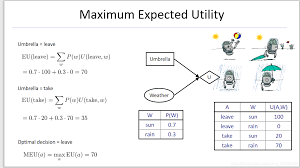

- Decisions as Outcome treees are almost exactly like expectimax/MDPs except the probabilities of chance nodes can be harder to compute and require Bayes net inference
- Above is decision tree, below is outcome tree:
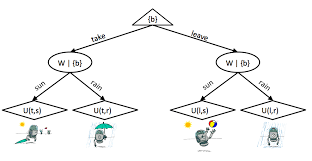

## Value of Informtation
- Idea is to compute the value of acquiring specific evidence.
  - This can be done directly from a decision Net.
- *Value* - expected gain in MEU from new info.
- *VPI* - value of perfect information (not wrong info).
- Recall: *mutually exclusive* - two things cannot exist simultaneously
- Simple example:
  - Two blocks; A and B, exactly one has oil worth k
  - you can only drill in one location
  - prior probabilities are 0.5 each
  - Drilling in either A or B has EU = k/2, MEU = k/2
- In this scenario, what is the Value of information of O (which place has oil)?
  - If we know OilLoc, MEU is k (either way)
  - VPI(OilLoc) = k/2
  - Fair price of information: k/2



### General VPI Formula + example
- $\text{VPI}(E'|e) = \left( \sum_{e'} P(e'|e) \cdot \text{MEU}(e, e') \right) - \text{MEU}(e)$
  - `e` = current evidence
  - `E'` - new variable we might obserge
  - `e'` - possible values of new variable we might observe

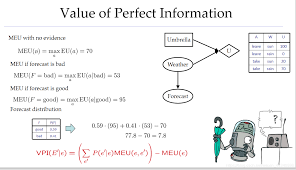

- e = Θ (no evidence)
- E' = forecast (new var)
- e' = possible values of forecast - {good,bad}
- MEU(e) = MEU(Θ) = 70
  - because action=leave -> 70, action = take = 35 and 70 > 35
- MEU(e,e') = MEU(Θ,good) = 95
- MEU(e,e') = MEU(Θ,bad) = 53
- $\text{VPI}(F|\emptyset) = \Big[ P(\text{good}|\emptyset) \cdot \text{MEU}(\emptyset, \text{good})
+ P(\text{bad}|\emptyset) \cdot \text{MEU}(\emptyset, \text{bad}) \Big] - \text{MEU}(\emptyset)$
  - $\text{VPI}(F|\emptyset) = (0.59 \times 95) + (0.41 \times 53) - 70$
  - VPI(F|Θ) = 7.8

## Value of Info continued
- Assume we have evidence E = e. Value if we act now:
  - $\text{MEU}(e) = \max_a \sum_s P(s \mid e) \, U(s, a)$
  - For each action, you compute its expected utility by summing over all possible states $  s  $, weighted by their probability given the current evidence. Whichever action gives the biggest summation is the one that provides the max utililty.
- Then assume we see more evidence E'=e'. The value if we act then would be:
  - $$\text{MEU}(e, e') = \max_a \sum_s P(s \mid e, e') \, U(s, a)$$
  - Simply updating the beliefs given more evidence.
- Most of the time we don't know what e' will be because E' is a random variable whose value is unknown.
- In this case, expected value if E' is revealed and then we act:
  - $\text{MEU}(e, E') = \sum_{e'} P(e' \mid e) \, \text{MEU}(e, e')$
- And as we did in the above example, the **value of information** - how much MEU goes up by revealing E' then acting
  - Basically measures how much better you expect to do in terms of utility if you get to observe E' first, then act compared to acting immediatley with only e MEU(e)
  - $\text{VPI}(E' \mid e) = \text{MEU}(e, E') - \text{MEU}(e)$

### VPI Properties
- Cannot be negative guaranteed!
  - ∀E',e: VPI(E'|e) >= 0
- Nonadditive (observing the same thing twice does not double the value of knowint that information)
  - $VPI(E_j,E_k|e) \ne VPI(E_j|e) + VPI(E_k|E)$
- Order-independent:
  - $\text{VPI}(E_j, E_k \mid e) = \text{VPI}(E_j \mid e) + \text{VPI}(E_k \mid e, E_j)$
    - How much expected utility improves if you get both peices of evidence before acting = how much you improve by only getting j first + how much additional improvement you get from k after you've already seen j
  - $\text{VPI}(E_j, E_k \mid e) = \text{VPI}(E_k \mid e) + \text{VPI}(E_j \mid e, E_k)$
    - Also true if we flip around the variables
  - The total value of getting both variables = value of getting the first one + the remaining value of getting the second one given you already have the first.


